# Autoencoders for RNA-seq data

_**With solutions for the exercises**_

In this notebook we work with **high-dimensional data**, meaning we have many more features than samples. High dimensionality can be **challenging** because distances and similarities become less informative and models can **overfit** more easily (often summarized as the **curse of dimensionality**).

A common clinical data type with very high feature counts is sequencing data. In **RNA-seq**, each sample is represented by expression values for thousands of genes, so the input space is naturally large. Here we use an autoencoder to learn a **compact latent representation** of RNA-seq profiles that can be used for visualization and downstream analyses. The dataset we use for this is called CPTAC. CPTAC (the Clinical Proteomic Tumor Analysis Consortium) is an NCI-led effort that provides large, public multi-omics datasets from patient tumors, with matched clinical annotations.

Goal:
- Load bulk [RNA-seq](https://en.wikipedia.org/wiki/RNA-Seq) data from [CPTAC](https://www.cell.com/consortium/cptac) via the `cptac` Python package
- Train an autoencoder to compress high-dimensional gene expression into a low-dimensional latent space
- Visualize reconstruction loss and latent representations (PCA)

In [ ]:
from google.colab import ai
response = ai.generate_text("Tell me what AI you are and can you help me with coding problems?")
print(response)

Hello!

I am a large language model, trained by Google.

**Can I help you with coding problems? Yes, absolutely!**

I can assist you with a wide range of coding-related tasks, including:

1.  **Debugging Code:** Help you identify errors in your code and suggest fixes.
2.  **Writing Code Snippets:** Generate code for specific functions, algorithms, or data structures.
3.  **Explaining Concepts:** Clarify programming concepts, algorithms, design patterns, or specific language features.
4.  **Optimizing Code:** Suggest ways to make your code more efficient, readable, or performant.
5.  **Code Translation:** Help translate code from one programming language to another.
6.  **Understanding Error Messages:** Break down complex error messages into understandable terms and suggest solutions.
7.  **Best Practices:** Provide guidance on best coding practices for various languages and scenarios.
8.  **Project Planning (Conceptual):** Discuss approaches to structuring your code or planning out a p

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap

## 1) Load CPTAC dataset (RNA-seq)

We use the `cptac` package, which provides programmatic access to CPTAC cohorts as pandas DataFrames.

Notes:
- On first use, the dataset may download and cache locally (can take a bit, depending on cohort).
- CPTAC cohorts contain multiple omics layers; we focus on transcriptomics (RNA-seq).

In [ ]:
!pip install cptac # should take around 2-3 min
import cptac

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 72.5 MB/s eta 0:00:00
  Created wheel for sorted_nearest: filename=sorted_nearest-0.0.41-cp312-cp312-linux_x86_64.whl size=6699045 sha256=c4b54aa87e241b23849cf17756ea3e9dc5556c9be1a10d36259070d55a3fa44d
  Stored in directory: /root/.cache/pip/wheels/7c/cb/a4/a6f831a60e479b9001be190e91000cc472addeab871957e5a9
Successfully built sorted_nearest


Now, lets see what data we have available in this package.

In [ ]:
cptac.get_source_options()

Cancer
Source     Datatype                                                              
bcm        CNV                  [brca, gbm, ov, ucec, pdac, coad, luad, ccrcc,...
           circular_RNA               [hnscc, gbm, ucec, pdac, luad, ccrcc, lscc]
           miRNA                [hnscc, brca, gbm, ucec, pdac, coad, luad, ccr...
           phosphoproteomics    [hnscc, brca, gbm, ov, ucec, pdac, coad, luad,...
           proteomics           [hnscc, brca, gbm, ov, ucec, pdac, coad, luad,...
           transcriptomics      [hnscc, brca, gbm, ov, ucec, pdac, coad, luad,...
broad      transcriptomics      [hnscc, brca, gbm, ov, ucec, pdac, coad, luad,...
harmonized ancestry_prediction                                      [all_cancers]
           somatic_mutation                                         [all_cancers]
mssm       clinical                                                 [all_cancers]
umich      acetylproteomics                         [brca, gbm, ucec, luad, lscc]
           phosphoproteomics    [hnscc, brca, gbm, ucec, pdac, coad, luad, ccr...
           proteomics           [hnscc, brca, gbm, ov, ucec, pdac, coad, luad,...
washu      CNV                  [hnscc, brca, gbm, ov, ucec, pdac, coad, luad,...
           cibersort            [hnscc, brca, gbm, ov, ucec, pdac, coad, luad,...
           hla_typing                                               [all_cancers]
           mature_miRNA               [hnscc, gbm, ucec, pdac, luad, ccrcc, lscc]
           precursor_miRNA            [hnscc, gbm, ucec, pdac, luad, ccrcc, lscc]
           somatic_mutation        [hnscc, gbm, ov, ucec, pdac, coad, luad, lscc]
           total_miRNA                [hnscc, gbm, ucec, pdac, luad, ccrcc, lscc]
           transcriptomics      [hnscc, brca, gbm, ov, ucec, pdac, coad, luad,...
           tumor_purity                                             [all_cancers]
           xcell                [hnscc, brca, gbm, ov, ucec, pdac, coad, luad,...

## 2) Get RNA-seq matrix

CPTAC uses multiple data sources; transcriptomics is typically available as a dataframe with gene expressions as columns and patients as rows.
We’ll:
- extract transcriptomics counts for several cancer types
- combine them into one big dataframe
- drop samples with missing values

In [ ]:
cohort_classes = [
    ("Brca", cptac.Brca),
    ("Ccrcc", cptac.Ccrcc),
    ("Colon", cptac.Coad),
    ("Gbm", cptac.Gbm),
    ("Luad", cptac.Luad),
    ("Ovarian", cptac.Ov),
    ("Pdac", cptac.Pdac),
    ("Ucec", cptac.Ucec),]

source = "bcm"

dfs = []
loaded = []

for name, cls in cohort_classes:
    cohort = cls()
    tx = cohort.get_transcriptomics(source)
    tx = tx.copy()
    tx["cancer_type"] = name
    dfs.append(tx)
    loaded.append((name, tx.shape))
    print(f"Loaded {name}: {tx.shape}")
print("\nLoaded cohorts:", loaded)

Loaded Brca: (133, 60592)


Loaded Ccrcc: (185, 59287)


Loaded Colon: (106, 60592)


Loaded Gbm: (100, 59287)


Loaded Luad: (213, 59287)


Loaded Ovarian: (101, 60592)


Loaded Pdac: (212, 59287)


Loaded Ucec: (119, 59287)

Loaded cohorts: [('Brca', (133, 60592)), ('Ccrcc', (185, 59287)), ('Colon', (106, 60592)), ('Gbm', (100, 59287)), ('Luad', (213, 59287)), ('Ovarian', (101, 60592)), ('Pdac', (212, 59287)), ('Ucec', (119, 59287))]


In [ ]:
dfs[0] # please have a look how many genes there are in this dataset

Name,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A2MP1,A3GALT2,...,ZXDC,ZYG11A,ZYG11AP1,ZYG11B,ZYX,ZYXP1,ZZEF1,hsa-mir-1253,hsa-mir-423,cancer_type
Database_ID,ENSG00000121410.12,ENSG00000268895.6,ENSG00000148584.15,ENSG00000175899.15,ENSG00000245105.4,ENSG00000166535.20,ENSG00000256661.1,ENSG00000256904.1,ENSG00000256069.7,ENSG00000184389.9,...,ENSG00000070476.15,ENSG00000203995.10,ENSG00000232242.2,ENSG00000162378.13,ENSG00000159840.16,ENSG00000274572.1,ENSG00000074755.15,ENSG00000272920.1,ENSG00000266919.3,
Patient_ID,,,,,,,,,,,,,,,,,,,,,
01BR001,3.51,8.04,0.00,12.93,5.01,4.88,0.0,0.0,3.13,0.00,...,8.88,7.07,0.0,9.86,10.63,0.0,10.05,0.0,0.0,Brca
01BR008,2.84,8.24,2.50,13.02,5.67,10.10,0.0,0.0,0.00,0.00,...,8.84,8.60,0.0,8.44,11.36,0.0,10.20,0.0,0.0,Brca
01BR009,4.85,8.11,0.00,13.68,5.87,9.50,0.0,0.0,3.11,0.00,...,8.85,3.64,0.0,8.90,10.58,0.0,10.54,0.0,0.0,Brca
01BR010,4.24,7.96,0.00,12.64,4.82,5.03,0.0,0.0,1.33,0.00,...,8.31,8.28,0.0,9.28,12.40,0.0,10.42,0.0,0.0,Brca
01BR015,3.89,7.56,1.58,13.55,5.32,3.31,0.0,0.0,2.99,0.00,...,9.05,5.08,0.0,10.13,10.44,0.0,10.46,0.0,0.0,Brca
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21BR002,0.00,7.86,0.00,13.96,6.51,1.12,0.0,0.0,0.00,1.74,...,9.79,5.47,0.0,8.97,11.72,0.0,10.18,0.0,0.0,Brca
21BR010,3.50,6.83,1.43,14.57,6.76,0.00,0.0,0.0,3.49,0.00,...,9.14,4.63,0.0,11.22,8.95,0.0,10.19,0.0,0.0,Brca


In [ ]:
expr_dfs = [d.drop(columns=["cancer_type"]) for d in dfs]
labels = pd.concat([d["cancer_type"] for d in dfs], axis=0)

# Find common genes across cohorts
common_genes = set(expr_dfs[0].columns)
for d in expr_dfs[1:]:
    common_genes &= set(d.columns)
common_genes = sorted(common_genes)
print("Common genes across loaded cohorts:", len(common_genes))

expr = pd.concat([d[common_genes] for d in expr_dfs], axis=0)
print("Combined expression shape:", expr.shape)
print("Labels shape:", labels.shape)

Common genes across loaded cohorts: 59286
Combined expression shape: (1169, 59286)
Labels shape: (1169,)


In [ ]:
expr = expr.dropna(axis=0, how="any")
expr = expr.dropna(axis=1, how="any")

labels_all = labels.loc[expr.index]

## 3) Train/validation split + scaling

Autoencoders are trained to reconstruct the input.
We scale features so training is stable:
- fit scaler on training set only
- apply to validation set

In [ ]:
y = labels_all.values

X = expr.values.astype(np.float32)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

train_ds = TensorDataset(torch.tensor(X_train_s), torch.tensor(X_train_s))
val_ds   = TensorDataset(torch.tensor(X_val_s), torch.tensor(X_val_s))
test_ds  = TensorDataset(torch.tensor(X_test_s), torch.tensor(X_test_s))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

input_dim = X_train_s.shape[1]
print("Input dim:", input_dim)
print("Train/Val/Test:", X_train_s.shape[0], X_val_s.shape[0], X_test_s.shape[0])

Input dim: 59286
Train/Val/Test: 748 187 234


## 4) Define an autoencoder

An **autoencoder** is a neural network trained to **reconstruct its input**. It consists of an **encoder** that compresses the data into a **low-dimensional latent embedding**, and a **decoder** that reconstructs the original data from that embedding.

We use autoencoders to learn **compact representations** of high-dimensional data (e.g., gene expression) in an unsupervised way. The latent embeddings can then be used for visualization (PCA/UMAP), clustering, denoising, or as features for downstream prediction models.

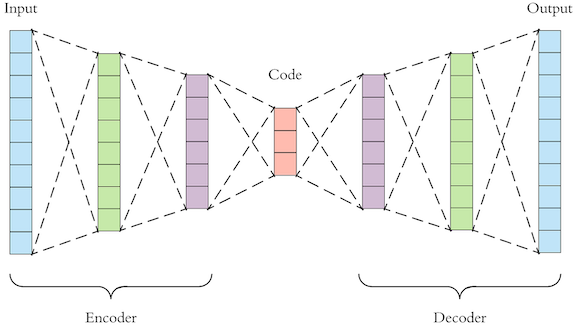

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim1=4096, hidden_dim2=1024, latent_dim=512):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

In this case, our loss is the **Mean Squared Error (MSE)**. MSE is used when the model is predicting continuous-valued outputs, because it penalizes how far each predicted value is from the target value. In an autoencoder, the target is the original input vector itself (e.g., gene expression levels), so the decoder is doing regression of continuous features rather than predicting discrete class labels.

In [ ]:
device = torch.device("cuda")
print("Device:", device)

model = Autoencoder(input_dim=input_dim).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)


Device: cuda
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=59286, out_features=4096, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4096, out_features=1024, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1024, out_features=512, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=512, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=4096, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4096, out_features=59286, bias=True)
  )
)


## 5) Training loop



In [ ]:
def run_epoch_ae(model, loader, criterion, optimizer=None, device="cpu"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            x_hat, _ = model(xb)
            loss = criterion(x_hat, yb)

            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * xb.size(0)
        n += xb.size(0)

    return total_loss / n

In [ ]:
num_epochs = 20

train_losses = []
val_losses = []

for epoch in range(1, num_epochs + 1):
    tr_loss = run_epoch_ae(model, train_loader, criterion, optimizer=optimizer, device=device)
    va_loss = run_epoch_ae(model, val_loader, criterion, optimizer=None, device=device)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)

    if epoch == 1 or epoch % 10 == 0 or epoch == num_epochs:
        print(f"Epoch {epoch:03d}/{num_epochs} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f}")

Epoch 001/20 | train_loss=0.9412 | val_loss=0.7188
Epoch 010/20 | train_loss=0.5130 | val_loss=0.5801
Epoch 020/20 | train_loss=0.4851 | val_loss=0.5865


## 6) Plot reconstruction loss

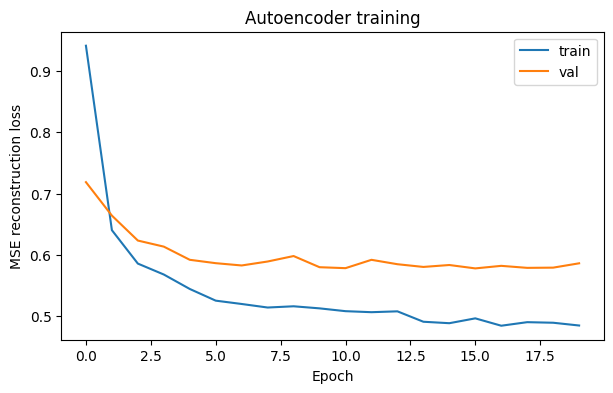

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE reconstruction loss")
plt.title("Autoencoder training")
plt.legend()
plt.show()

## 7) Extract latent space + PCA visualization

We encode samples into a latent vector `z` (e.g. 128 dims),
then project to 2D with PCA for visualization.

In [ ]:
@torch.no_grad()
def get_latent(model, X_scaled, device="cpu", batch_size=512):
    model.eval()
    zs = []
    loader = DataLoader(torch.tensor(X_scaled, dtype=torch.float32),
                        batch_size=batch_size, shuffle=False)
    for xb in loader:
        xb = xb.to(device)
        _, z = model(xb)
        zs.append(z.cpu())
    return torch.cat(zs, dim=0).numpy()

Z_test  = get_latent(model, X_test_s, device=device)

print("Z_train shape:", Z_test.shape)

Z_train shape: (234, 512)


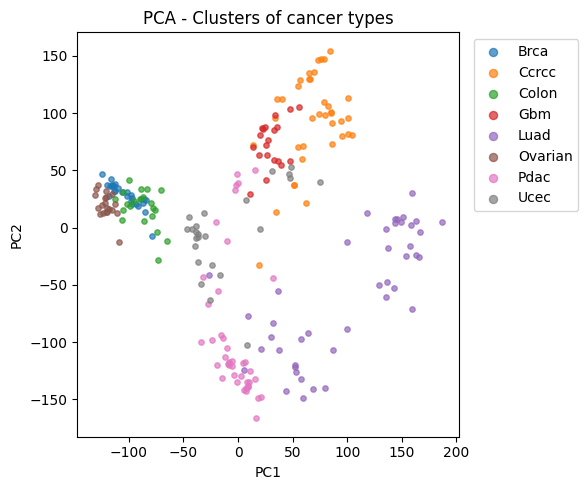

Explained variance (PC1+PC2): 0.326


In [ ]:
pca = PCA(n_components=2, random_state=42)
Z2 = pca.fit_transform(Z_test)

plt.figure(figsize=(6,5))
for ct in np.unique(y_test):
    m = (y_test == ct)
    plt.scatter(Z2[m, 0], Z2[m, 1], s=15, alpha=0.7, label=ct)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Clusters of cancer types")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=1.5)
plt.tight_layout()
plt.show()

print("Explained variance (PC1+PC2):", pca.explained_variance_ratio_.sum().round(3))

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


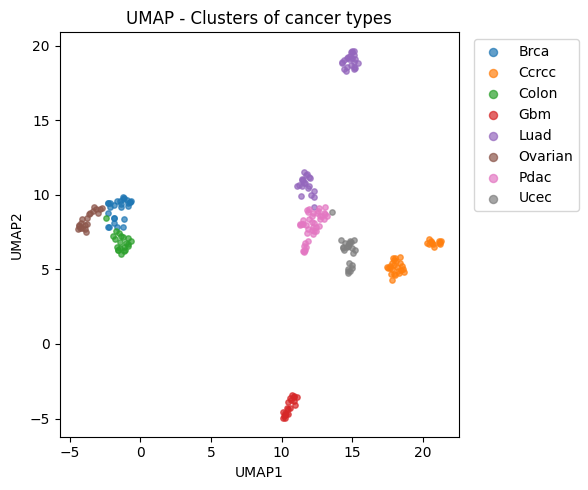

In [ ]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.3,
    metric="euclidean",
    random_state=42
)

Z2 = reducer.fit_transform(Z_test)

plt.figure(figsize=(6,5))
for ct in np.unique(y_test):
    m = (y_test == ct)
    plt.scatter(Z2[m, 0], Z2[m, 1], s=15, alpha=0.7, label=ct)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP - Clusters of cancer types")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=1.5)
plt.tight_layout()
plt.show()